
## Core ML
* working with the data and write a better code
* Explore the data and  make a story out of it
* Data is the experince if you don't work with the data then you are not a data scientest

* If you don't have assunptions from the data that;s wrong , you need to put enough effort
* The model must be robust  


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
from sklearn.model_selection import train_test_split


In [ ]:
from abc import abstractmethod,ABC
class DataInspectionStrat(ABC):
  @abstractmethod
  def inspect(self, df : pd.DataFrame):
    """
    Performs access to a dataframe

    Parameters:
      df (pd.DataFrame) : The dataFrame which would be accessed

    Returns :
      None as it justs accesses the dataframe
    """
    pass

class DatatypesInspectionStrat(DataInspectionStrat):
  def inspect(self , df : pd.DataFrame):
    """
    Inspects the datatypes in the dataFrame

    Parameters
      df (pd.DataFrame): The dataframe to be inspected

    Returns:
      None, Just prints the datatypes to be used
      """
    print("\nData Types and non null counts")
    print(df.info())

class StatisiticsSummaryInspection(DataInspectionStrat):
  def inspect(self, df : pd.DataFrame):
    """
    Inspects the DataFrame for the summary of the statisitics

    Parameters:
      df(pd.DataFrame): The dataframe to be inspected

    Returns:
      None, and prints the summary of the statisitics
    """
    print("\nSummary of Statistics :")
    print(df.describe())
    print("\nSummary for categorical Variables :")
    print(df.describe(include=['O']))


class DataInspector:
  def __init__(self,strategy : DataInspectionStrat):
    """
    initialize the dataInspector class with a specific inspection

    Parameters:
    Stratagy that you want to use

    Returns:
    None
    """
    self._strategy = strategy

  def set_strat(self,strategy:DataInspectionStrat):
    """
    Sets a new strategy for the data inspector

    Parameters:
      Strategy (DataInspectorStrat): The new strat to be applied
    Returns:
      None
    """
    self._strategy = strategy

  def executeStrat(self, df:pd.DataFrame):
    """
    Execute the strat that we are working on the df

    Parameters:
      df (pandas Data Frame)which is the data that the Start will
      be applied on
    Returns:
      None, Just executes the current start on the df
    """
    self._strategy.inspect(df)





In [ ]:
function_tester_dict = {'A':[1,2,3,4,np.nan],
                        'B':np.arange(5),
                        'C':np.random.randint(size=[5],high=10,low=0)}

In [ ]:
function_tester_dict

{'A': [1, 2, 3, 4, nan],
 'B': array([0, 1, 2, 3, 4]),
 'C': array([5, 3, 7, 4, 4])}

In [ ]:
df = pd.DataFrame(data=function_tester_dict,)

In [ ]:
df

,A,B,C
0,1.0,0,5
1,2.0,1,3
2,3.0,2,7
3,4.0,3,4
4,NaN,4,4


In [ ]:
inspecter = DataInspector(DataInspectionStrat)

In [ ]:
inspecter.set_strat(StatisiticsSummaryInspection())

In [ ]:
df = pd.read_csv('MyData/housing.csv')

# Inspect The Data

In [ ]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
inspecter.executeStrat(df)


Summary of Statistics :
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    20433.000000  20640.000000  20640.000000   20640.000000   
mean       537.870553   1425.476744    499.539680       3.870671   
std        421.385070   1132.462122    382.329753       1.899822   
min          1.000000      3.000000      1.000000       0.49990

In [ ]:
inspecter.set_strat(strategy=DatatypesInspectionStrat())

In [ ]:
inspecter.executeStrat(df)


Data Types and non null counts
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

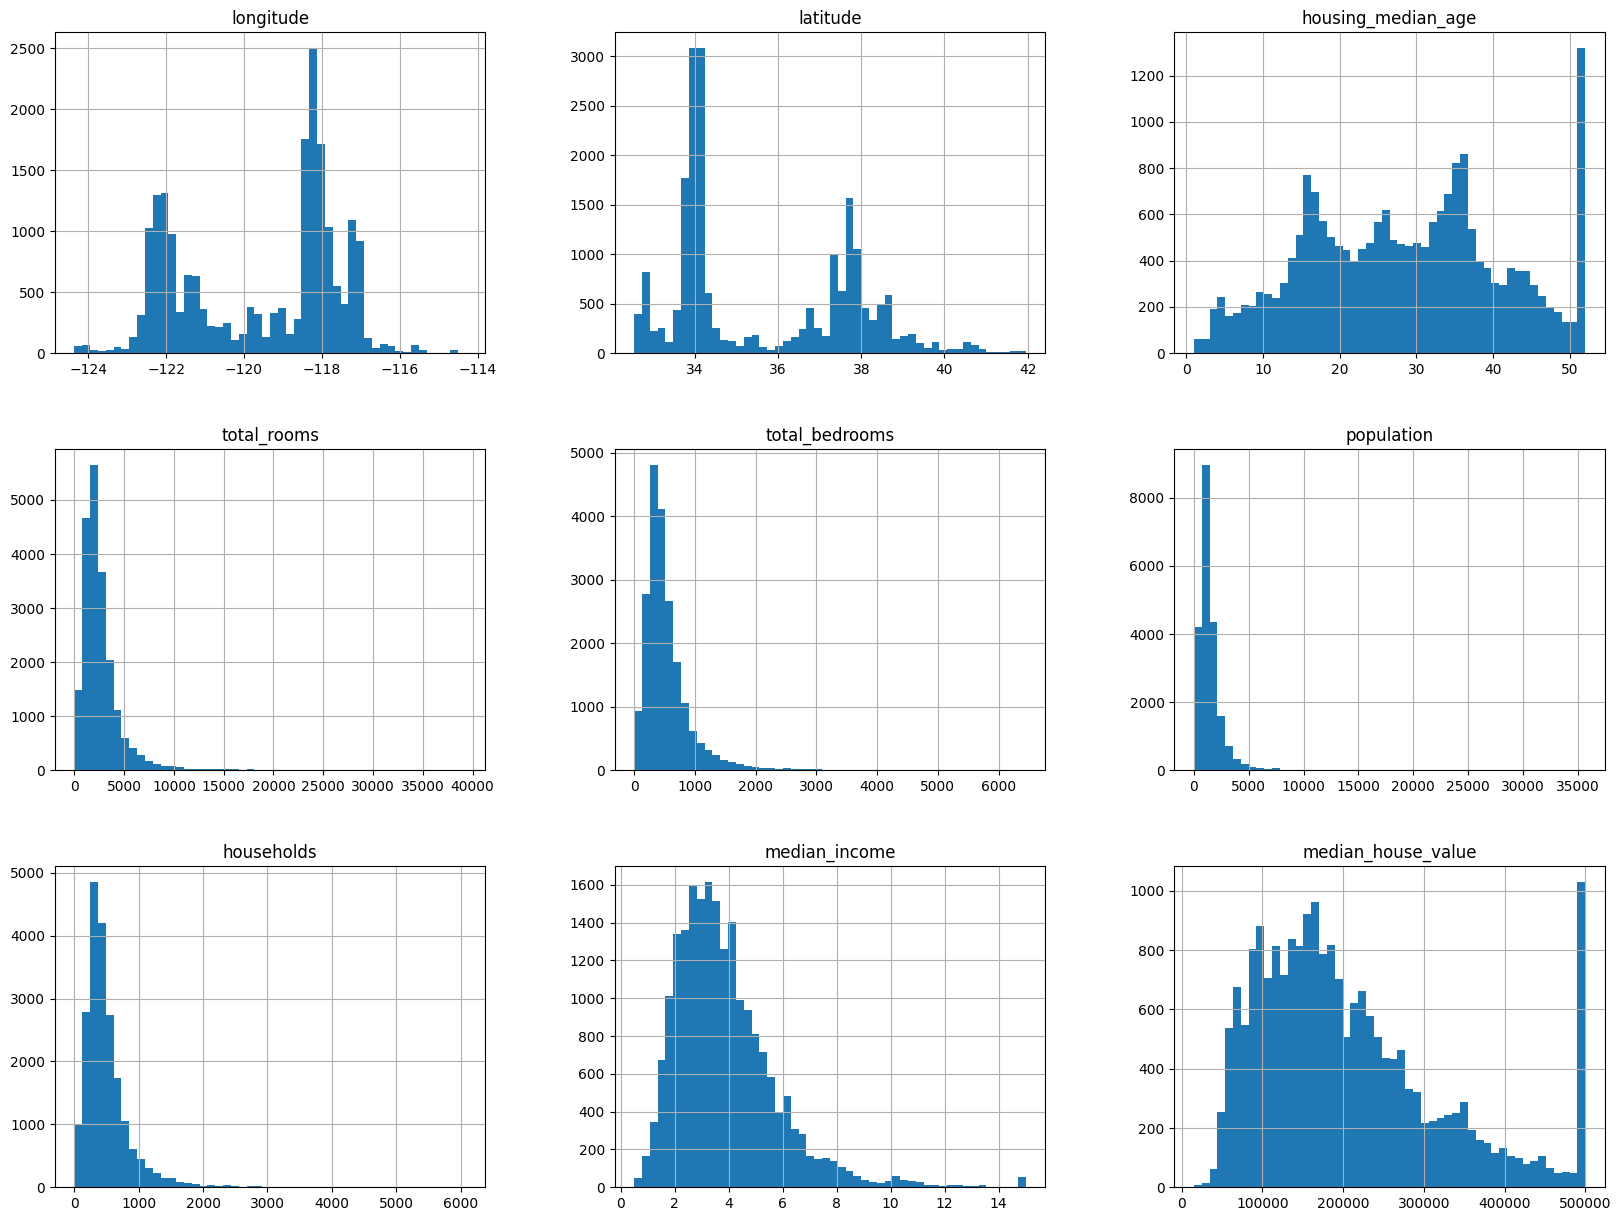

In [ ]:
df.hist(bins=50,figsize=(20,15))

- The mean household value is capped at a number and it's not in usd it's scalled
  - 5 is 50000
- The graphs are all tailed which means they are scalled
- The graphs are also not with the same scale shiche means we need to scale them back

# Create Test Train sets

In [ ]:
train_set,test_set = train_test_split(df,test_size=0.2,random_state=42,stratify=None)

## Note
- It's fine to do random sampling if the data is much bigger than the number of attributes
- You have to make sure when the data is collected that the sample is correct
- Stratify means that if there is 80% something and 20% it makes the smaple has almost the same thing

## Data insight

The median income should be a very good metric for the median house value



In [ ]:
df[df.columns.drop('ocean_proximity')].corr()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


As we can see from the correlation
the highest correlation is between the income and the value
so let's  make the income a categorical value as to make a trainning and testing sets that explain the population well

# Finding relationships

In [ ]:
df['income_cat'] = pd.cut(df['median_income'],
                          bins = [0.,1.5,3.0,4.5,6,np.inf],
                          labels=[1,2,3,4,5])

<Axes: >

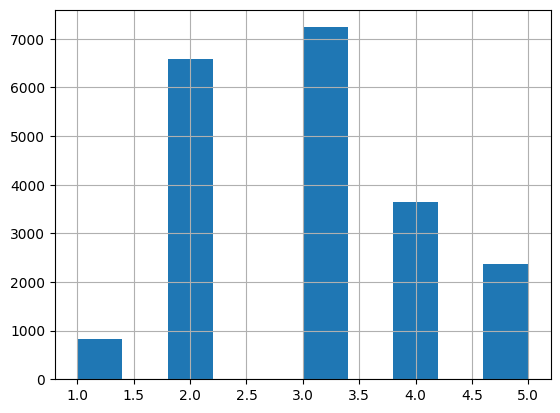

In [ ]:
df['income_cat'].hist()

As we can see here most people have 30000 usd

Now we should make a Stratified sample to get a training a set that's correct and explains the whole population


In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(
    n_splits=1, # Rememeber we only need one SPLIT here
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(df, df["income_cat"])
)

train_df = df.loc[train_idx].reset_index(drop=True)
test_df  = df.loc[test_idx].reset_index(drop=True)


In [ ]:
test_df["income_cat"].value_counts() / len(test_df)

,count
income_cat,
3,0.350533
2,0.318798
4,0.176357
5,0.114341
1,0.039971


In [ ]:
train_df["income_cat"].value_counts() / len(train_df)

,count
income_cat,
3,0.350594
2,0.318859
4,0.176296
5,0.114462
1,0.039789


Both are the same so we can say the train and test sets explain the population well
We can now drop the income_cat as it might bias the model

In [ ]:
for dataSet in (train_df,test_df):
  dataSet.drop('income_cat',axis=1,inplace=True)

In [ ]:
house = train_df.copy()

<Axes: xlabel='longitude', ylabel='latitude'>

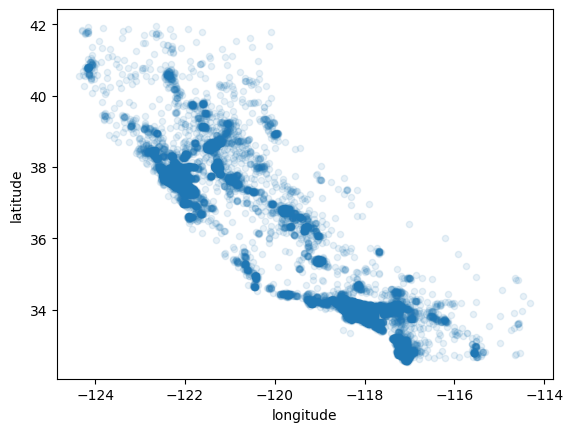

In [ ]:
house.plot(kind='scatter',x='longitude',y='latitude',alpha = 0.1)

This is the map for california but it shows where the high destiny for the houses are

We need to make it appear more clearly so how about we make the color depend on the price

<Axes: xlabel='longitude', ylabel='latitude'>

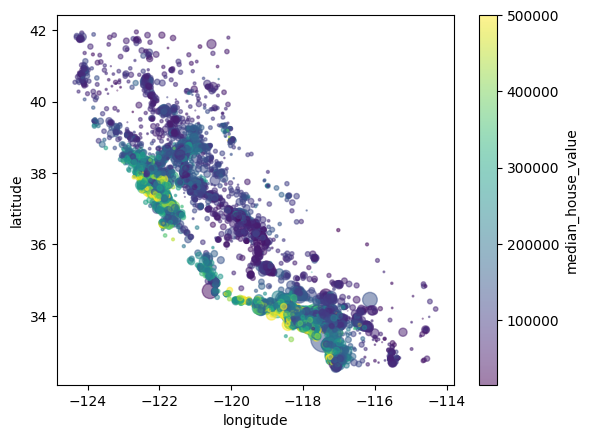

In [ ]:
house.plot(kind='scatter',x='longitude',y='latitude',alpha = 0.5,
           c='median_house_value',
           s=house['population']/100)

from what can be seen is the price depend on the area that we are in and that if we are near the ocean the price increases except when there's a lot of people





<Axes: >

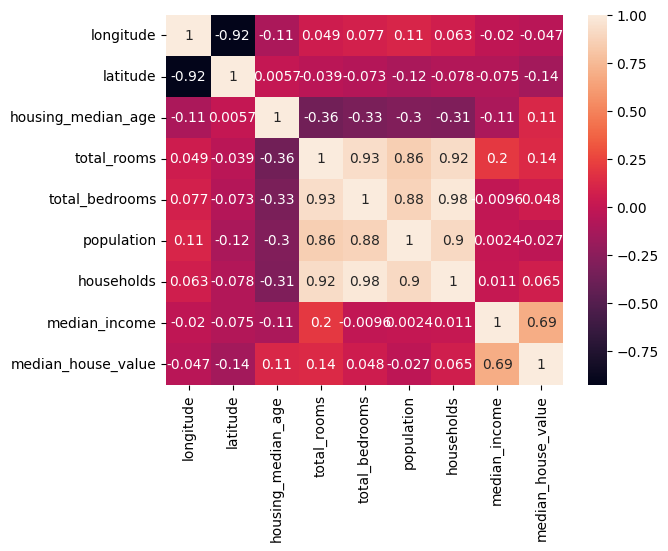

In [ ]:
corr_matrix = house.corr(numeric_only=True)
sns.heatmap(corr_matrix,annot=True)

<Axes: xlabel='median_income', ylabel='median_house_value'>

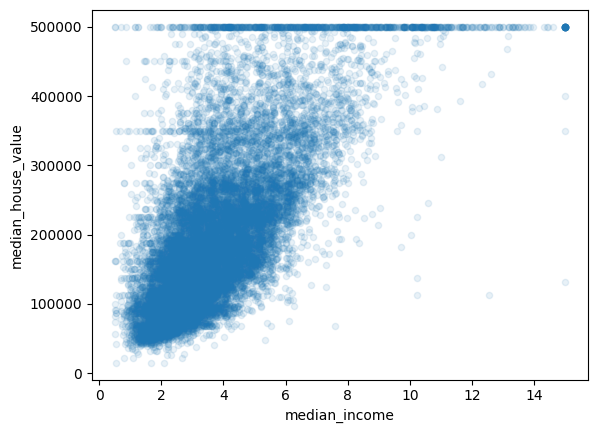

In [ ]:
house.plot(x='median_income',y='median_house_value',
         kind='scatter',alpha=0.1)

As we can see here it's pretty linear until like 350,000 where there's a constant value and also at 450,000

It will be better to find if there's another realtion before ml so the model will learn better




# Making the data more usable
Total bedrooms and total rooms isn't great to get insight from so we need to make them usable by dividing them from the households


In [ ]:
house['room_per_household'] = house['total_rooms']/house['households']
house['bedroom_per_household'] = house['total_bedrooms']/house['households']
house['population_per_house'] = house['population']/house['households']
house

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,room_per_household,bedroom_per_household,population_per_house
0,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,72100.0,INLAND,5.485836,1.128895,3.168555
1,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,279600.0,NEAR OCEAN,6.927083,1.113281,2.623698
2,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,82700.0,INLAND,5.393333,1.033333,2.223333
3,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,112500.0,NEAR OCEAN,3.886128,1.074534,1.859213
4,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,238300.0,<1H OCEAN,6.096552,1.113793,3.167241
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16507,-117.07,33.03,14.0,6665.0,1231.0,2026.0,1001.0,5.0900,268500.0,<1H OCEAN,6.658342,1.229770,2.023976
16508,-121.42,38.51,15.0,7901.0,1422.0,4769.0,1418.0,2.8139,90400.0,INLAND,5.571932,1.002821,3.363188
16509,-122.72,38.44,48.0,707.0,166.0,458.0,172.0,3.1797,140400.0,<1H OCEAN,4.110465,0.965116,2.662791
16510,-122.70,38.31,14.0,3155.0,580.0,1208.0,501.0,4.1964,258100.0,<1H OCEAN,6.297405,1.157685,2.411178


So now let's see if there's a better relationship

In [ ]:
corr_matrix = house.corr(numeric_only=True)
corr_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,room_per_household,bedroom_per_household,population_per_house
longitude,1.000000,-0.924478,-0.105823,0.048909,0.076686,0.108071,0.063146,-0.019615,-0.047466,-0.028374,0.012765,-0.000415
latitude,-0.924478,1.000000,0.005737,-0.039245,-0.072550,-0.115290,-0.077765,-0.075146,-0.142673,0.107665,0.070595,0.005426
housing_median_age,-0.105823,0.005737,1.000000,-0.364535,-0.325101,-0.298737,-0.306473,-0.111315,0.114146,-0.147184,-0.075330,0.015031
total_rooms,0.048909,-0.039245,-0.364535,1.000000,0.929391,0.855103,0.918396,0.200133,0.135140,0.127549,0.026444,-0.024806
total_bedrooms,0.076686,-0.072550,-0.325101,0.929391,1.000000,0.876324,0.980167,-0.009643,0.047781,0.000426,0.042778,-0.028364
population,0.108071,-0.115290,-0.298737,0.855103,0.876324,1.000000,0.904639,0.002421,-0.026882,-0.074665,-0.068423,0.076232
households,0.063146,-0.077765,-0.306473,0.918396,0.980167,0.904639,1.000000,0.010869,0.064590,-0.082971,-0.058382,-0.027411
median_income,-0.019615,-0.075146,-0.111315,0.200133,-0.009643,0.002421,0.010869,1.000000,0.687151,0.311528,-0.058923,0.021815
median_house_value,-0.047466,-0.142673,0.114146,0.135140,0.047781,-0.026882,0.064590,0.687151,1.000000,0.146255,-0.043349,-0.021991
room_per_household,-0.028374,0.107665,-0.147184,0.127549,0.000426,-0.074665,-0.082971,0.311528,0.146255,1.000000,0.863207,-0.005316


In [ ]:
corr_matrix['median_house_value'].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.687151
room_per_household,0.146255
total_rooms,0.135140
housing_median_age,0.114146
households,0.064590
total_bedrooms,0.047781
population_per_house,-0.021991
population,-0.026882
bedroom_per_household,-0.043349


In [ ]:
house = train_set.drop('median_house_value',axis=1)
house_label = train_set['median_house_value']

So we have null values which must be dealt with
There are multiplie ways i will just use the median

In [ ]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')

In [ ]:
house_numerical = house.drop('ocean_proximity',axis = 1)

In [ ]:
imputer.fit(house_numerical)

SimpleImputer(strategy='median')

In [ ]:
X = imputer.transform(house_numerical)
house_train = pd.DataFrame(X,columns=house_numerical.columns)

Now we dealt with the missing values of the numerical features in the dataset
We now need to deal with the categorical value which will either change each value into number or just make them dummy values by making the categorical variable into multiple binary columns

In [ ]:
house_cat = house['ocean_proximity']

In [ ]:
house_cat = pd.get_dummies(house_cat)

In [ ]:
house_cat

,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
14196,False,False,False,False,True
8267,False,False,False,False,True
17445,False,False,False,False,True
14265,False,False,False,False,True
2271,False,True,False,False,False
...,...,...,...,...,...
11284,True,False,False,False,False
11964,False,True,False,False,False
5390,True,False,False,False,False
860,True,False,False,False,False


In [ ]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):

    def __init__(
        self,
        rooms_ix,
        bedrooms_ix,
        population_ix,
        households_ix,
        add_bedrooms_per_room=True
    ):
        self.rooms_ix = rooms_ix
        self.bedrooms_ix = bedrooms_ix
        self.population_ix = population_ix
        self.households_ix = households_ix
        self.add_bedrooms_per_room = add_bedrooms_per_room

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        rooms = X[:, self.rooms_ix]
        bedrooms = X[:, self.bedrooms_ix]
        population = X[:, self.population_ix]
        households = X[:, self.households_ix]

        rooms_per_household = np.divide(
            rooms, households, out=np.zeros_like(rooms), where=households != 0
        )

        population_per_household = np.divide(
            population, households, out=np.zeros_like(population), where=households != 0
        )

        features = [rooms_per_household, population_per_household]

        if self.add_bedrooms_per_room:
            bedrooms_per_room = np.divide(
                bedrooms, rooms, out=np.zeros_like(bedrooms), where=rooms != 0
            )
            features.append(bedrooms_per_room)

        return np.c_[X, *features]


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

numeric_features = house_numerical.columns.tolist()
categorical_features = ["ocean_proximity"]

rooms_ix = house_numerical.columns.get_loc("total_rooms")
bedrooms_ix = house_numerical.columns.get_loc("total_bedrooms")
population_ix = house_numerical.columns.get_loc("population")
households_ix = house_numerical.columns.get_loc("households")

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("attribs_adder", CombinedAttributesAdder(
        rooms_ix,
        bedrooms_ix,
        population_ix,
        households_ix,
        add_bedrooms_per_room=True
    )),
    ("scaler", StandardScaler()),
])

full_pipeline = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"),
     categorical_features),
])

house_prepared = full_pipeline.fit_transform(house)


In [ ]:
house_prepared.shape

(16512, 16)

# Train the Model
We can choose something wasy like linear regression to do the job

In [ ]:
from sklearn.linear_model import LinearRegression
lin_model = LinearRegression()
lin_model.fit(house_prepared,house_label)

LinearRegression()

In [ ]:
from sklearn.metrics import mean_squared_error
house_pred = lin_model.predict(house_prepared)
lin_error = mean_squared_error(house_label,house_pred)
root_lin_error = np.sqrt(lin_error)
print("Root mean Squared Error",root_lin_error)
print("R-Squared",lin_model.score(house_prepared,house_label))

Root mean Squared Error 67593.20745775253
R-Squared 0.6582199160539229


This model is under achiving so we meed to make it better (R^2 closer to 1)

In [ ]:
from sklearn.tree import DecisionTreeRegressor
tree_mod = DecisionTreeRegressor()
tree_mod.fit(house_prepared,house_label)

DecisionTreeRegressor()

In [ ]:
house_pred = tree_mod.predict(house_prepared)
tree_error = mean_squared_error(house_label,house_pred)
root_tree_error = np.sqrt(tree_error)
print('Root mean Squared Error',root_tree_error)
print('R-Squared',tree_mod.score(house_prepared,house_label))

Root mean Squared Error 0.0
R-Squared 1.0


This Model is Overfitted if we go and try using it on the evaluation dataset it will give very bad results

Let's use Cross Validation first to decrease the overfitting

In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(tree_mod,house_prepared,
                         house_label,
                         scoring="neg_mean_squared_error",
                         cv = 10)
root_tree_error = np.sqrt(-scores)
print(root_tree_error)
print("Mean Of the Scores",root_tree_error.mean())

[65215.87624902 70702.20846712 70421.69105531 71448.22604352
 73799.15865024 67076.00305075 65729.39335527 68487.17633446
 68166.53703312 71356.6719339 ]
Mean Of the Scores 69240.29421727135



As we can see it's performing badly the linear regression model so let's make it better using random forest


In [ ]:
from sklearn.ensemble import RandomForestRegressor
forest_mod = RandomForestRegressor()
forest_mod.fit(house_prepared,house_label)


RandomForestRegressor()

In [ ]:
scores = cross_val_score(forest_mod,house_prepared,
                         house_label,
                         scoring="neg_mean_squared_error",
                         cv = 10)
root_forest_error = np.sqrt(-scores)
print(root_forest_error)
print("Mean Of the Scores",root_forest_error.mean())

[46717.0013919  51701.65855821 49562.7635494  51849.23507945
 52364.14903498 47649.81591177 47461.09335292 50637.5845094
 49268.92349779 49743.8104518 ]
Mean Of the Scores 49695.60353376267


Better than both but it can still be better so we need to fine tune it

# FineTuning the Model

There are multiple ways to do fine tuning like using ensemble methods, grid search and more i will go with grid search to choose the parameters in the random forest and since random forest is already an ensembled decision tree i am not far of it

In [ ]:
from sklearn.model_selection import GridSearchCV


In [ ]:
param_grid = {'n_estimators':[5,15,30],
               'max_features':[2,4,6,8],
               'bootstrap':[True,False]}
forest_mod = RandomForestRegressor()
grid_search = GridSearchCV(forest_mod,param_grid,cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)
grid_search.fit(house_prepared,house_label)


GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'bootstrap': [True, False],
                         'max_features': [2, 4, 6, 8],
                         'n_estimators': [5, 15, 30]},
             return_train_score=True, scoring='neg_mean_squared_error')

In [ ]:
grid_search.best_params_

{'bootstrap': False, 'max_features': 6, 'n_estimators': 30}

In [ ]:
grid_search.best_estimator_

RandomForestRegressor(bootstrap=False, max_features=6, n_estimators=30)

In [ ]:
cv_results = grid_search.cv_results_

results = zip(
    cv_results["mean_test_score"],
    cv_results["params"]
)

for score, params in sorted(results, key=lambda x: x[0], reverse=True):
    rmse = np.sqrt(-score)
    print(f"RMSE: {rmse:.4f} | Params: {params}")


RMSE: 48767.8223 | Params: {'bootstrap': False, 'max_features': 6, 'n_estimators': 30}
RMSE: 49338.9228 | Params: {'bootstrap': False, 'max_features': 4, 'n_estimators': 30}
RMSE: 49442.4532 | Params: {'bootstrap': False, 'max_features': 8, 'n_estimators': 30}
RMSE: 50037.5333 | Params: {'bootstrap': False, 'max_features': 6, 'n_estimators': 15}
RMSE: 50049.3224 | Params: {'bootstrap': True, 'max_features': 4, 'n_estimators': 30}
RMSE: 50090.4628 | Params: {'bootstrap': False, 'max_features': 4, 'n_estimators': 15}
RMSE: 50104.2062 | Params: {'bootstrap': True, 'max_features': 6, 'n_estimators': 30}
RMSE: 50270.6706 | Params: {'bootstrap': True, 'max_features': 8, 'n_estimators': 30}
RMSE: 50288.9796 | Params: {'bootstrap': False, 'max_features': 8, 'n_estimators': 15}
RMSE: 50501.5184 | Params: {'bootstrap': True, 'max_features': 8, 'n_estimators': 15}
RMSE: 51324.3771 | Params: {'bootstrap': True, 'max_features': 4, 'n_estimators': 15}
RMSE: 51535.0873 | Params: {'bootstrap': False, 

In [ ]:
feature_importance = grid_search.best_estimator_.feature_importances_
feature_importance

array([7.53620602e-02, 6.63130711e-02, 4.15219357e-02, 1.56699304e-02,
       1.56152522e-02, 1.59652049e-02, 1.45398522e-02, 3.70763899e-01,
       4.89762876e-02, 1.06122951e-01, 7.23413567e-02, 1.79140882e-02,
       1.32614821e-01, 2.29816623e-04, 2.64574612e-03, 3.40372713e-03])

In [ ]:
cat_encoder = full_pipeline.named_transformers_["cat"]

cat_one_hot_attribs = cat_encoder.get_feature_names_out(categorical_features)


In [ ]:
extra_attribs = [
    "rooms_per_household",
    "population_per_household",
    "bedrooms_per_room",
]


In [ ]:
cat_one_hot_attribs

array(['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'], dtype=object)

In [ ]:
attributes = (
    numeric_features
    + extra_attribs
    + list(cat_one_hot_attribs)
)
attributes


['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'rooms_per_household',
 'population_per_household',
 'bedrooms_per_room',
 'ocean_proximity_<1H OCEAN',
 'ocean_proximity_INLAND',
 'ocean_proximity_ISLAND',
 'ocean_proximity_NEAR BAY',
 'ocean_proximity_NEAR OCEAN']

In [ ]:
feature_importances = grid_search.best_estimator_.feature_importances_

importance_sorted = sorted(
    zip(feature_importances, attributes),
    reverse=True
)

for score, name in importance_sorted:
    print(f"{name:30s} {score:.4f}")


median_income                  0.3708
ocean_proximity_INLAND         0.1326
population_per_household       0.1061
longitude                      0.0754
bedrooms_per_room              0.0723
latitude                       0.0663
rooms_per_household            0.0490
housing_median_age             0.0415
ocean_proximity_<1H OCEAN      0.0179
population                     0.0160
total_rooms                    0.0157
total_bedrooms                 0.0156
households                     0.0145
ocean_proximity_NEAR OCEAN     0.0034
ocean_proximity_NEAR BAY       0.0026
ocean_proximity_ISLAND         0.0002


# Evaluating this on the test set that the model didn't see at all

In [ ]:
finalMod = grid_search.best_estimator_
X_test = test_df.drop("median_house_value",axis = 1)
y_test = test_df['median_house_value'].copy()


In [ ]:
X_test_prep = full_pipeline.fit_transform(X_test)
X_test_prep

array([[ 0.57507019, -0.69657252,  0.0329564 , ...,  0.        ,
         0.        ,  0.        ],
       [-0.43480141, -0.33466769, -0.36298077, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.54522177, -0.63547171,  0.58726843, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.08656982, -0.54617051,  1.14158047, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.81385757, -0.92687559,  0.11214383, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.49049967, -0.66367208,  0.58726843, ...,  0.        ,
         0.        ,  0.        ]])

In [ ]:
final_pred = finalMod.predict(X_test_prep)
final_mse = mean_squared_error(y_test, final_pred)
final_rmse = np.sqrt(final_mse)
print(final_rmse)

61239.90047136929
